In [20]:
import torch
from segment_anything import sam_model_registry, SamPredictor
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [14]:
def leggi_coordinate_csv(file_path):
    # Leggi il file CSV
    df = pd.read_csv(file_path)
    
    # Estrai le colonne 'pixel_x' e 'pixel_y' e convertili in una lista di tuple
    coppie = list(zip(df['pixel_x'], df['pixel_y']))
    
    return coppie

In [10]:
sam_checkpoint = "sam_vit_h_4b8939.pth"  # Sostituisci con il percorso corretto del checkpoint
model_type = "vit_h"  # Può essere "vit_h", "vit_b" o "vit_l"
device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)
predictor = SamPredictor(sam)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0..596].


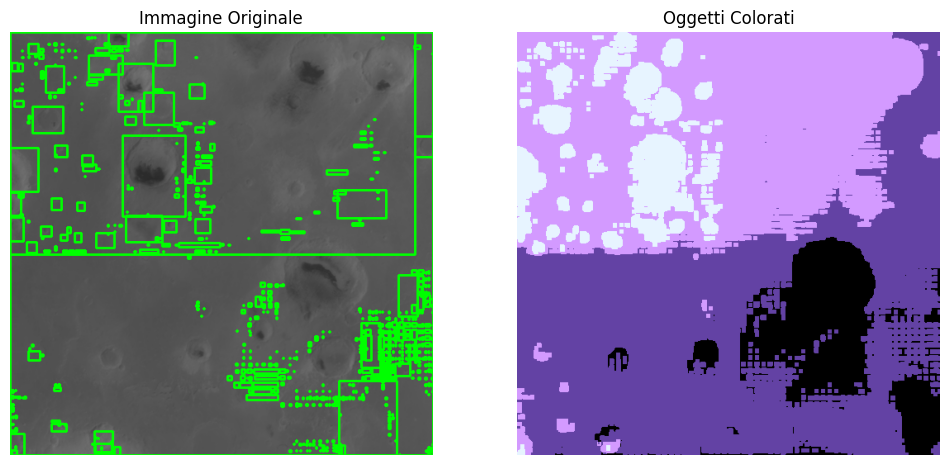

In [31]:
# Carica l'immagine
image_path = 'immagini_sam/immagine_6_30.png'  # Sostituisci con il percorso della tua immagine
image_gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
image_rgb = cv2.cvtColor(image_gray, cv2.COLOR_GRAY2RGB)

# Specifica i punti di interesse
# Esempio: lista di punti di interesse (x, y)
points_of_interest = leggi_coordinate_csv('csv_sam/crateri_6_30.csv')  # Sostituisci con le tue coordinate


# Converti i punti in un formato adatto per il modello
input_points = torch.tensor(points_of_interest, dtype=torch.float).unsqueeze(0).to(device)
input_labels = torch.tensor([1] * len(points_of_interest)).unsqueeze(0).to(device)

# Genera le maschere di segmentazione utilizzando i punti di interesse
predictor.set_image(image_rgb)
masks, scores, logits = predictor.predict_torch(
    point_coords=input_points,
    point_labels=input_labels,
    multimask_output=True
)

# Ottieni le maschere come array NumPy
masks_np = masks[0].cpu().numpy()

# Trova i contorni delle maschere di segmentazione
contours = []
for mask in masks_np:
    mask = np.uint8(mask * 255)
    
    # Gestione dei contorni basata sulla versione di OpenCV
    if cv2.__version__.startswith('4'):  # OpenCV 4.x
        contours_, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    else:  # OpenCV 3.x e precedenti
        _, contours_, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    contours.extend(contours_)

# Disegna le bounding box sugli oggetti segmentati
for contour in contours:
    # Calcola il rettangolo delimitatore per il contorno
    x, y, w, h = cv2.boundingRect(contour)
    
    # Disegna il rettangolo delimitatore sull'immagine RGB
    cv2.rectangle(image_rgb, (x, y), (x + w, y + h), (0, 255, 0), 2)  # Colore verde, spessore 2

# Visualizza l'immagine con le bounding box
#fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

#ax1.imshow(image_rgb)
#ax1.set_title('Immagine Originale con Bounding Box')
#ax1.axis('off')

# Etichetta gli oggetti nelle maschere
num_objects = masks_np.shape[0]
labels = np.zeros((num_objects, image_rgb.shape[0], image_rgb.shape[1], 3), dtype=np.uint8)  # Inizializza array per i colori

for i in range(num_objects):
    # Applica una trasformazione morfologica (ad es. dilatazione) per unire le aree e facilitare l'etichettatura
    mask = np.uint8(masks_np[i] * 255)
    mask = cv2.dilate(mask, np.ones((5, 5), np.uint8), iterations=1)
    
    # Etichetta ciascun oggetto
    _, labeled_mask = cv2.connectedComponents(mask)
    
    # Genera un colore casuale per l'oggetto
    color = np.random.randint(0, 255, size=3)
    
    # Applica il colore solo alle posizioni dove labeled_mask ha valori diversi da zero
    color_mask = np.zeros_like(image_rgb)
    color_mask[labeled_mask > 0] = color
    
    # Aggiungi il colore al set di label
    labels[i] = color_mask



# Combina tutte le etichette per ottenere l'immagine colorata
colored_image = np.sum(labels, axis=0)

# Visualizza l'immagine originale e l'immagine colorata
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.imshow(image_rgb)
ax1.set_title('Immagine Originale')
ax1.axis('off')

ax2.imshow(colored_image)
ax2.set_title('Oggetti Colorati')
ax2.axis('off')

plt.show()